> **Versão pública.** Este notebook rodou no Google Colab, com os dados e artefatos numa pasta do Google Drive do grupo. Para reproduzir, veja [Como reproduzir](../../README.md#como-reproduzir).

# Imports e Configuração de Ambiente

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

In [ ]:
drive.flush_and_unmount()

In [ ]:
import os
import sys
sys.path.insert(0, os.path.dirname('/content/drive/My Drive/<PASTA_DE_BIBLIOTECAS>/')) 

In [ ]:
import AleTransforms as trf
import AleDatasetAnalysis as dat
import AleMLAnalysis as aml
import AleLearnersSeriesMultiGradient as lrn

In [ ]:
import importlib
importlib.reload(trf)
importlib.reload(dat)
importlib.reload(aml)
importlib.reload(lrn)

<module 'AleLearnersSeriesMultiGradient' from '/content/drive/My Drive/<PASTA_DE_BIBLIOTECAS>/AleLearnersSeriesMultiGradient.py'>

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gc

In [ ]:
import tensorflow as tf

# Acessando API do Kaggle

In [ ]:
#Instala a API
!pip install kaggle

In [ ]:
# Move minhas credenciais para a pasta em que a API foi instalada
!mkdir -p ~/.kaggle/ && cp -i /content/drive/My Drive/<PASTA_DE_BIBLIOTECAS>/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Baixa dos dados do Projeto, descompacta e deleta arquivo zip
!kaggle datasets download -d paultimothymooney/kermany2018 && unzip kermany2018.zip && rm kermany2018.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8050636-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-3.jpeg  
[... 4985 linhas omitidas na versão pública ...]
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-4872585-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5156112-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5171640-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5193994-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val

# Visualização dos Dados

In [ ]:
!ls /content/OCT2017\ /train/NORMAL | head -5

NORMAL-1001666-1.jpeg
NORMAL-1001772-1.jpeg
NORMAL-1001772-2.jpeg
NORMAL-1001772-3.jpeg
NORMAL-1001772-4.jpeg


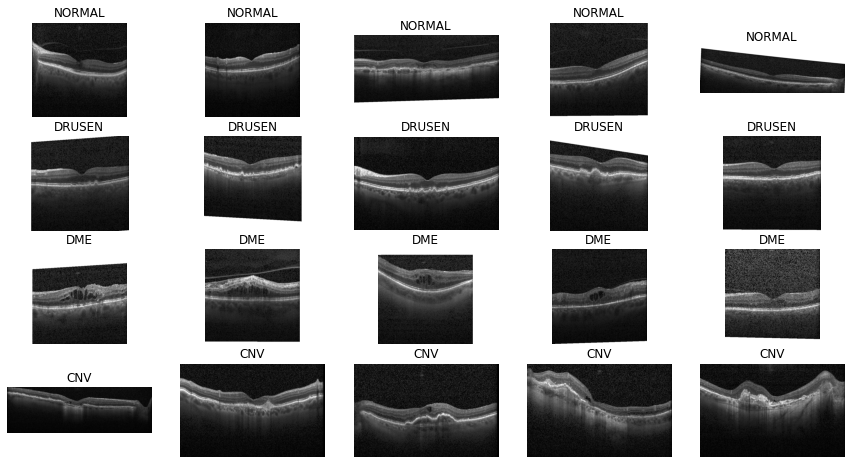

In [ ]:
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']
num_img = 5

fig, ax = plt.subplots(len(labels_folders), num_img, figsize = (int(3*num_img), 2*len(labels_folders)))
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, num_img):
      img_matrix = np.matrix(Image.open(path + lista_imagens[i]))
      ax[j][i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
      ax[j][i].set_title(label)
      ax[j][i].set_axis_off()
plt.show()

# Padronização das Imagens: Deixar mesma proporção e do mesmo tamanho

In [ ]:
shapes = []
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  print(label)
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  shapes.extend([np.matrix(Image.open(path + img)).shape for img in lista_imagens])

NORMAL
DRUSEN
DME
CNV


In [ ]:
shape_mediano = (int(np.median([s[0] for s in shapes])), int(np.median([s[1] for s in shapes])))
print(shape_mediano)

shape_min = (int(np.min([s[0] for s in shapes])), int(np.min([s[1] for s in shapes])))
shape_max = (int(np.max([s[0] for s in shapes])), int(np.max([s[1] for s in shapes])))
print(shape_min)
print(shape_max)

(496, 512)
(496, 384)
(512, 1536)


In [ ]:
#A ideia aqui é "esticar" a largura até o shape_max[1] e depois prolongar todas as imagens de forma de nenhuma seja cortada
shape_padrao = (int(np.ceil(np.max([s[0]*(shape_max[1]/s[1]) for s in shapes]))), shape_max[1])
print(shape_padrao)
fator = 0.05
fator2 = 3
shape_reduzido = (int(fator*shape_padrao[0])*(2**fator2), int(fator*shape_padrao[1])*(2**fator2))
print(shape_reduzido)

(1984, 1536)
(792, 608)


In [ ]:
shape_padrao = (1984, 1536)
shape_reduzido = (792, 608)

In [ ]:
def padroniza_imagem(img_pil, novo_shape):
  novo_shape = (novo_shape[1], novo_shape[0]) #Invete por na imagem o padrão é largura (colunas) e depois comprimento (linhas)
  #https://pillow.readthedocs.io/en/stable/reference/ImageOps.html
  img_size = img_pil.size
  zoom = novo_shape[0]/img_size[0] #Sempre >= 1 pelo shape_padrao definido
  if(zoom >= 1):
    return ImageOps.pad(ImageOps.scale(img_pil, zoom), size = novo_shape)
  else:
    return "Erro Inesperado"

def elimina_borda_brancas(img_matrix):
  limiar = 0.001
  nivel_branco = 250
  altura = img_matrix.shape[0]
  largura = img_matrix.shape[1]
  linha_max = int(altura/2)
  coluna_max = int(largura/2)

  #Filtra a parte superior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte inferior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[altura-1-i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[altura-1-i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte esquerda da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), i] = 0
    i = i + 1

  #Filtra a parte direita da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, largura-1-i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), largura-1-i] = 0
    i = i + 1

  return img_matrix

def compacta_imagem(img_matrix, shape_reduzido):
  img_pil = Image.fromarray(img_matrix)
  return np.matrix(ImageOps.pad(img_pil, size = (shape_reduzido[1], shape_reduzido[0])))

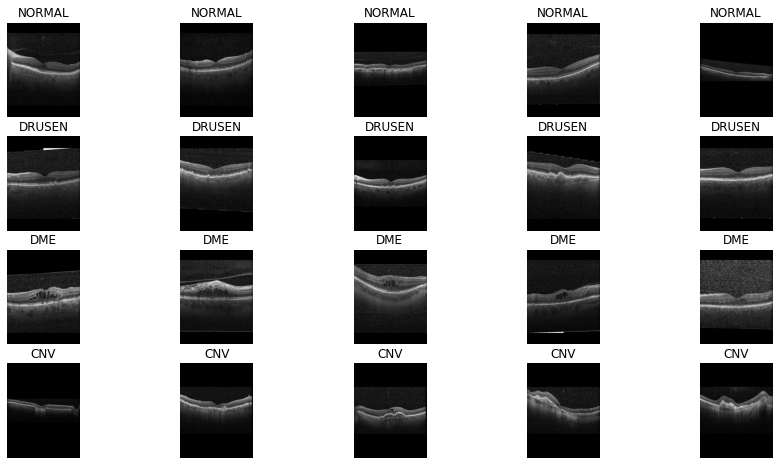

In [ ]:
fig, ax = plt.subplots(len(labels_folders), num_img, figsize = (int(3*num_img), 2*len(labels_folders)))
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, num_img):
      img_matrix = compacta_imagem(elimina_borda_brancas(np.matrix(padroniza_imagem(Image.open(path + lista_imagens[i]), shape_padrao))), shape_reduzido)
      ax[j][i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
      ax[j][i].set_title(label)
      ax[j][i].set_axis_off()
plt.show()

# Salva as imagens tratadas

In [ ]:
try:
  path = os.path.join('/content/drive/My Drive/<PASTA_DO_PROJETO>/', 'train')
  os.mkdir(path, 0o666)
except:
  pass

In [ ]:
path_saida = '/content/drive/My Drive/<PASTA_DO_PROJETO>/train'
for j in range(0, len(labels_folders)):
  label = labels_folders[j]

  try:
    os.mkdir(os.path.join(path_saida, label), 0o666)
  except:
    pass

  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, len(lista_imagens)):
      Image.fromarray(compacta_imagem(elimina_borda_brancas(np.matrix(padroniza_imagem(Image.open(path + lista_imagens[i]),
                                                                                       shape_padrao))), 
                                      shape_reduzido)).save(path_saida + '/' + label + '/' + lista_imagens[i])

In [ ]:
try:
  path = os.path.join('/content/drive/My Drive/<PASTA_DO_PROJETO>/', 'val')
  os.mkdir(path, 0o666)
except:
  pass

In [ ]:
path_saida = '/content/drive/My Drive/<PASTA_DO_PROJETO>/val'
for j in range(0, len(labels_folders)):
  label = labels_folders[j]

  try:
    os.mkdir(os.path.join(path_saida, label), 0o666)
  except:
    pass

  path = '/content/OCT2017 /val/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, len(lista_imagens)):
      Image.fromarray(compacta_imagem(elimina_borda_brancas(np.matrix(padroniza_imagem(Image.open(path + lista_imagens[i]),
                                                                                       shape_padrao))), 
                                      shape_reduzido)).save(path_saida + '/' + label + '/' + lista_imagens[i])

# Teste de Transformações nas Imagens

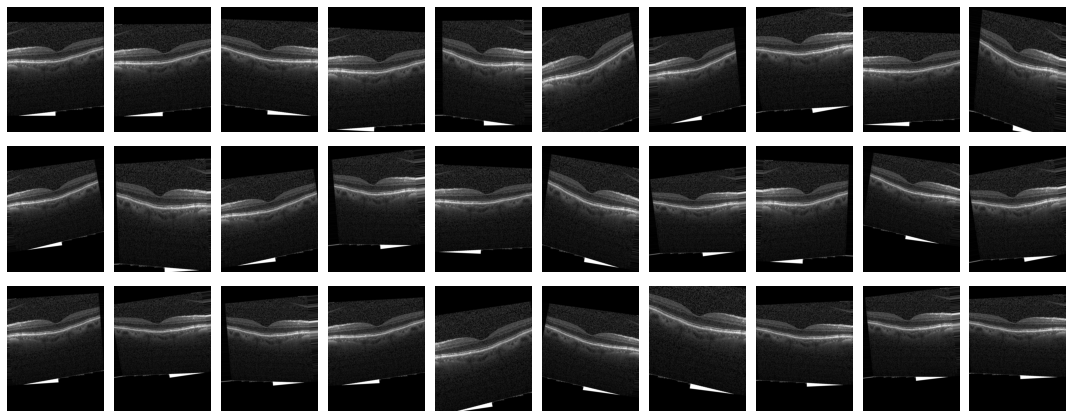

In [ ]:
# Visualizando as imagens transformadas
datagen_example = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.0, #Shifts grandes podem cortar áreas importantes lesão
    height_shift_range = 0.1,
    shear_range = 0.0, #distorção (pode distorcer a direção x e y de forma independente)
    zoom_range = 0.2, #zoom (pode dar zom na direção x e y de forma independente)
    horizontal_flip = True,
    vertical_flip = False,
    )

img = np.matrix(Image.open('/content/drive/My Drive/<PASTA_DO_PROJETO>/train/NORMAL/NORMAL-1001666-1.jpeg'))
img = np.expand_dims(img, axis = 2)
example_generator = datagen_example.flow(np.array([img]), batch_size=1)

num_row = 3
num_col = 10
num = num_row*num_col

fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
  if i == 0:
    X = img
  else:
    X = next(example_generator)[0]
  ax = axes[i//num_col, i%num_col]
  ax.imshow(X[:, :, 0], cmap='gray', vmin = 0, vmax = 255)
  ax.set_axis_off()
plt.tight_layout()
plt.show()

# Utilizando um Autoencoder para compactar as imagens e extrair as features

In [ ]:
batch_size = 16

autoencoder_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = 10,
    width_shift_range = 0.0, #Shifts grandes podem cortar áreas importantes lesão
    height_shift_range = 0.1,
    shear_range = 0.0, #distorção (pode distorcer a direção x e y de forma independente)
    zoom_range = 0.2, #zoom (pode dar zom na direção x e y de forma independente)
    horizontal_flip = True,
    vertical_flip = False,
    validation_split = 0.2
    )

train_generator = autoencoder_datagen.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/train/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        class_mode = "input",
        #class_mode = 'categorical',
        #shuffle = False,
        subset='training',)

valid_generator = autoencoder_datagen.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/train/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        class_mode = "input",
        #class_mode = 'categorical',
        #shuffle = False,
        subset='validation',)

steps_train = int(np.ceil(train_generator.samples/batch_size)*0.1)
steps_val = int(np.ceil(valid_generator.samples/batch_size)*0.1)

print(steps_train)
print(steps_val)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
417
104


In [ ]:
import keras
from keras import layers

In [ ]:
shape_img = (shape_reduzido[0], shape_reduzido[1], 1)
print(shape_img)

(792, 608, 1)


In [ ]:
encoding_dim = 128
shape_encoded = (8, 16)

input_img = keras.Input(shape = shape_img)

'''
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same', name = 'shape_ref')(x)
'''
x = layers.Conv2D(32, (3, 3), strides = 2, padding = "same")(input_img)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), strides = 2, padding = "same")(x)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), strides = 2, padding = "same")(x)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.BatchNormalization(name = 'shape_ref')(x)

##############################
# Parte comum a qualquer arquitetura de Autoencoder (permite dimensionar o espaço latente de forma arbitrária)
##############################

x = layers.Flatten(name = 'flatten')(x) # Adicionei para dar mais liberdade para escolher o número de dimensões no espaço latente
encoded = layers.Dense(encoding_dim, name = 'espaco_latente')(x)

# nesse ponto a representação é 32-dimensional (dado pelo encoding_dim)-> checar no summary

#Pega o número de neuronios na flatten, #pois precisamos reconstruí-los no decoder
num_flatten = keras.Model(input_img, encoded).get_layer('flatten').output_shape[1] 

#Pega o shape que devemos transformar o flatten
shape_ref = keras.Model(input_img, encoded).get_layer('shape_ref').output_shape[1:] 

x = layers.Dense(num_flatten)(encoded)
x = layers.Reshape(shape_ref)(x)

##############################
# Fim da parte comum
##############################

'''
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
'''
x = layers.Conv2DTranspose(128, (3, 3), strides = 2, padding = "same")(x)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, (3, 3), strides = 2, padding = "same")(x)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, (3, 3), strides = 2, padding = "same")(x)
x = layers.LeakyReLU(alpha = 0.2)(x)
x = layers.Conv2DTranspose(1, (3, 3), padding = "same")(x)
decoded = layers.Activation("sigmoid")(x)

autoencoder = keras.Model(input_img, decoded)
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 792, 608, 1)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 396, 304, 32)      320       
_________________________________________________________________
[... 40 linhas omitidas na versão pública ...]
conv2d_transpose_3 (Conv2DTr (None, 792, 608, 1)       289       
_________________________________________________________________
activation (Activation)      (None, 792, 608, 1)       0         
Total params: 247,844,097
Trainable params: 247,843,265
Non-trainable params: 832
_________________________________________________________________


In [ ]:
from keras.callbacks import ModelCheckpoint

model_checkpoint_callback = ModelCheckpoint(
    filepath = '/content/drive/My Drive/<PASTA_DO_PROJETO>/weights_autoencoder5.h5',
    save_best_only = True,
    save_weights_only = True,
    save_freq = 'epoch',
    monitor = 'val_loss',
    mode = 'min',
    verbose = 1)

history = autoencoder.fit(train_generator, steps_per_epoch = steps_train, epochs = 10, 
                          validation_data = valid_generator, validation_steps = steps_val,
                          callbacks=[model_checkpoint_callback])

Epoch 1/10
417/417 [==============================] - 312s 750ms/step - loss: 0.0023 - val_loss: 0.0022

Epoch 00001: val_loss improved from inf to 0.00218, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/weights_autoencoder5.h5
Epoch 2/10
417/417 [==============================] - 308s 741ms/step - loss: 0.0023 - val_loss: 0.0023

Epoch 00002: val_loss did not improve from 0.00218
Epoch 3/10
417/417 [==============================] - 304s 729ms/step - loss: 0.0023 - val_loss: 0.0025

Epoch 00003: val_loss did not improve from 0.00218
Epoch 4/10
417/417 [==============================] - 302s 724ms/step - loss: 0.0023 - val_loss: 0.0022

Epoch 00004: val_loss did not improve from 0.00218
Epoch 5/10
417/417 [==============================] - 300s 720ms/step - loss: 0.0022 - val_loss: 0.0022

Epoch 00005: val_loss did not improve from 0.00218
Epoch 6/10
417/417 [==============================] - 308s 739ms/step - loss: 0.0022 - val_loss: 0.0022

Epoch 00006: val_loss did not i

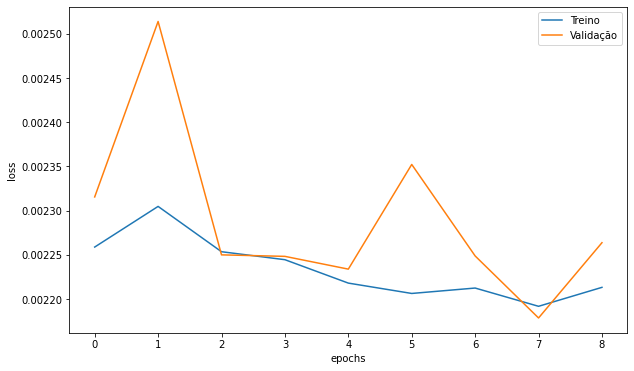

Loss Mínima: 0.0021785874851047993
Época da Loss Mínima: 9


In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history.history['loss'][1:], label = 'Treino')
ax.plot(history.history['val_loss'][1:], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history.history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history.history['val_loss'])))

In [ ]:
autoencoder.load_weights('/content/drive/My Drive/<PASTA_DO_PROJETO>/weights_autoencoder5.h5')

In [ ]:
encoder = keras.Model(input_img, encoded)

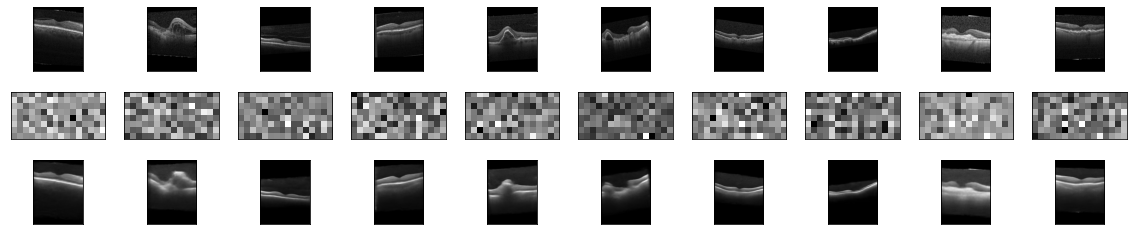

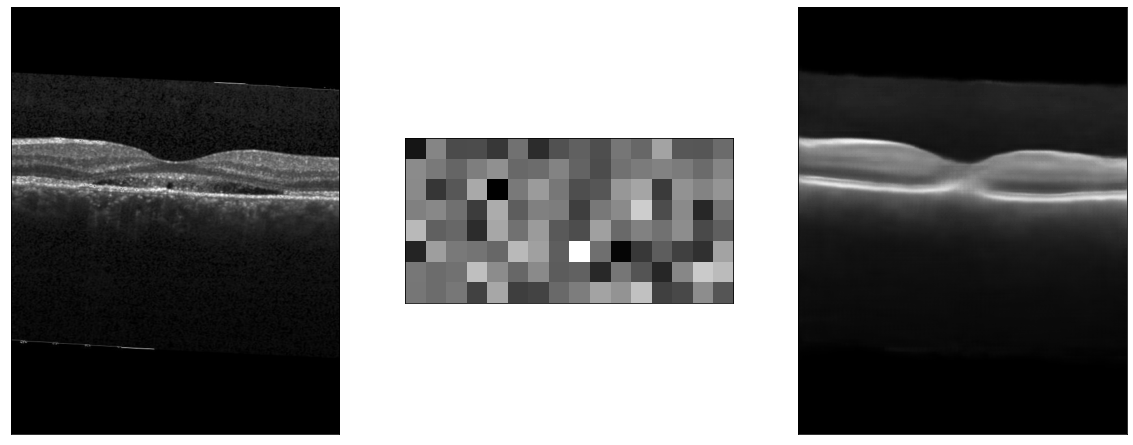

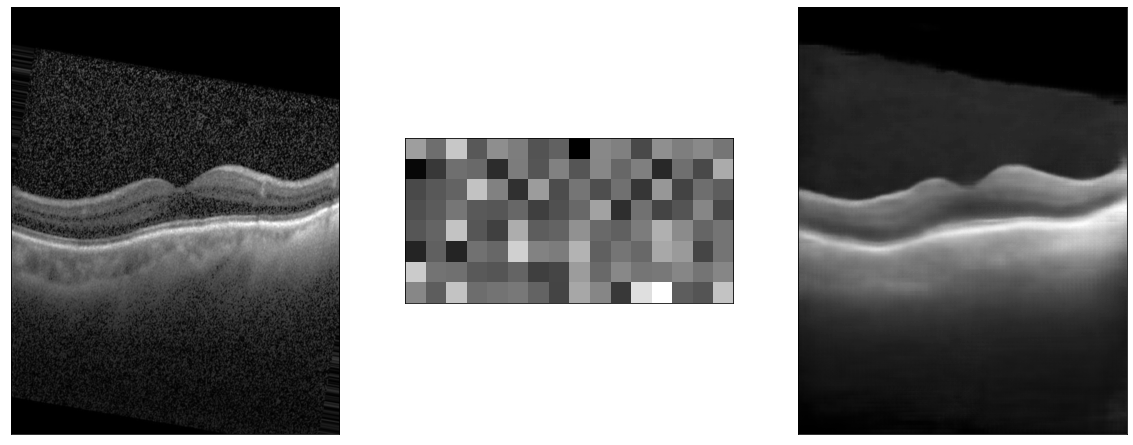

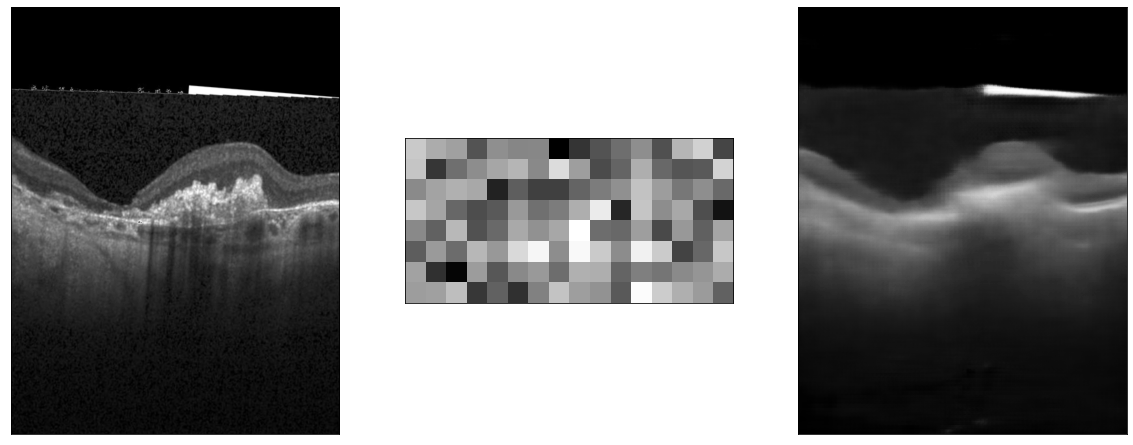

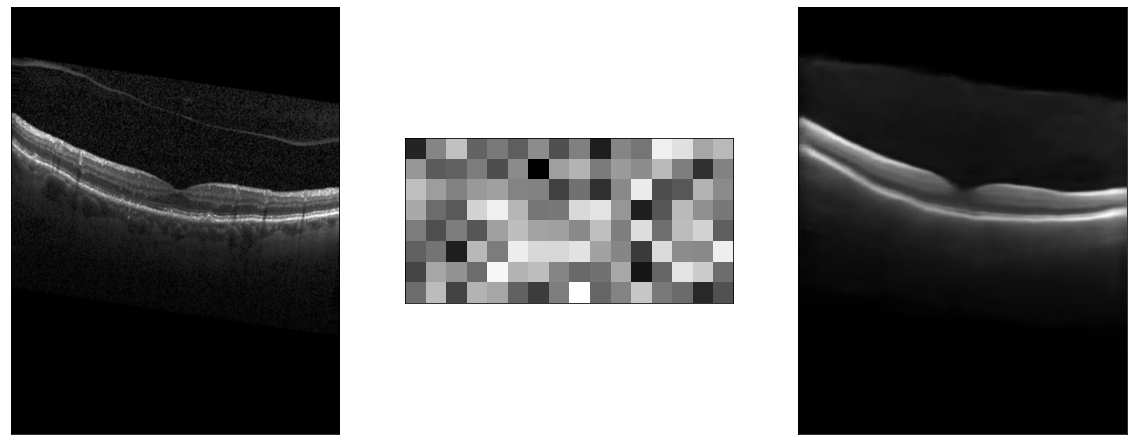

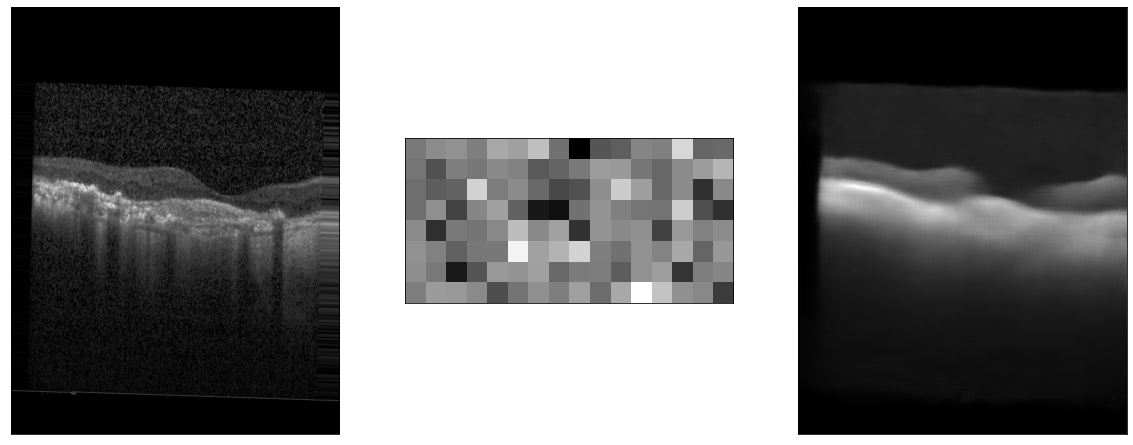

In [ ]:
x_exemplos = next(valid_generator)[0]

decoded_imgs = autoencoder.predict(x_exemplos)

encoded_imgs = encoder.predict(x_exemplos)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(3, n, i)

    plt.imshow(x_exemplos[i].reshape(shape_img[0], shape_img[1]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #Display encoded
    ax = plt.subplot(3, n, i + n)
    plt.imshow(encoded_imgs[i].reshape(shape_encoded))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(3, n, i + 2*n)
    plt.imshow(decoded_imgs[i].reshape(shape_img[0], shape_img[1]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

k = 5
for i in range(n+1, n+1+k):
  plt.figure(figsize=(20, 10))

  ax = plt.subplot(1, 3, 1)
  plt.imshow(x_exemplos[i].reshape(shape_img[0], shape_img[1]))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(1, 3, 2)
  plt.imshow(encoded_imgs[i].reshape(shape_encoded))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(1, 3, 3)
  plt.imshow(decoded_imgs[i].reshape(shape_img[0], shape_img[1]))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  plt.show()

# Catboost

In [ ]:
batch_size = 1024

modelo_datagen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.0, #Shifts grandes podem cortar áreas importantes lesão
    height_shift_range = 0.1,
    shear_range = 0.0, #distorção (pode distorcer a direção x e y de forma independente)
    zoom_range = 0.2, #zoom (pode dar zom na direção x e y de forma independente)
    horizontal_flip = True,
    vertical_flip = False,
    rescale = 1.0/255,
    validation_split = 0.2,
    )

'''
modelo_datagen_val = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale = 1.0/255,
    )

train_generator_modelo = modelo_datagen_train.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/train/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        #class_mode = "input",
        #shuffle = False,
        class_mode = 'categorical',)

valid_generator_modelo = modelo_datagen_val.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/val/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        #shuffle = False,
        class_mode = 'categorical',)
'''

train_generator_modelo = modelo_datagen_train.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/train/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        #class_mode = "input",
        class_mode = 'categorical',
        #shuffle = False,
        subset='training',)

valid_generator_modelo = modelo_datagen_train.flow_from_directory(
        '/content/drive/My Drive/<PASTA_DO_PROJETO>/train/',
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        follow_links = False,
        #class_mode = "input",
        class_mode = 'categorical',
        #shuffle = False,
        subset='validation',)

steps_train_modelo = int(np.ceil(train_generator_modelo.samples/batch_size))
steps_val_modelo = int(np.ceil(valid_generator_modelo.samples/batch_size))

print(steps_train_modelo)
print(steps_val_modelo)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
66
17


In [ ]:
x_train = np.empty(shape = (0, encoding_dim))
y_train = np.array([])
for i in range(0, steps_train_modelo):
  temp = next(train_generator_modelo)
  x_train = np.concatenate((x_train, encoder.predict(temp[0])), axis = 0)
  y_train = np.append(y_train, np.argmax(temp[1], axis = 1))
  del temp
  gc.collect()

In [ ]:
x_val = np.empty(shape = (0, encoding_dim))
y_val = np.array([])
for i in range(0, steps_val_modelo):
  temp = next(valid_generator_modelo)
  x_val = np.concatenate((x_val, encoder.predict(temp[0])), axis = 0)
  y_val = np.append(y_val, np.argmax(temp[1], axis = 1))
  del temp
  gc.collect()

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

clf_cat = CatBoostClassifier(iterations = 1000, learning_rate = 0.1, depth = 6)

clf_cat.fit(x_train, y_train, eval_set = (x_val, y_val), verbose = True, plot = False)

0:	learn: 1.3510644	test: 1.3525740	best: 1.3525740 (0)	total: 184ms	remaining: 3m 3s
1:	learn: 1.3212738	test: 1.3232848	best: 1.3232848 (1)	total: 349ms	remaining: 2m 54s
2:	learn: 1.2967474	test: 1.2990846	best: 1.2990846 (2)	total: 503ms	remaining: 2m 47s
3:	learn: 1.2764589	test: 1.2789733	best: 1.2789733 (3)	total: 651ms	remaining: 2m 42s
4:	learn: 1.2594154	test: 1.2624663	best: 1.2624663 (4)	total: 810ms	remaining: 2m 41s
5:	learn: 1.2436697	test: 1.2473137	best: 1.2473137 (5)	total: 974ms	remaining: 2m 41s
6:	learn: 1.2307799	test: 1.2349350	best: 1.2349350 (6)	total: 1.15s	remaining: 2m 43s
7:	learn: 1.2191584	test: 1.2237521	best: 1.2237521 (7)	total: 1.31s	remaining: 2m 42s
[... 988 linhas omitidas na versão pública ...]
996:	learn: 0.6674455	test: 0.8546965	best: 0.8546965 (996)	total: 2m 19s	remaining: 421ms
997:	learn: 0.6672088	test: 0.8546354	best: 0.8546354 (997)	total: 2m 19s	remaining: 280ms
998:	learn: 0.6669228	test: 0.8545751	best: 0.8545751 (998)	total: 2m 20s	r

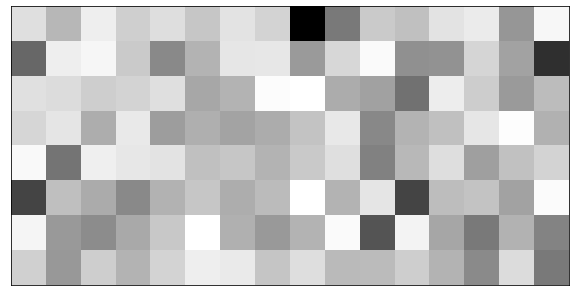

0         1
8      8  2.463662
31    31  2.038636
80    80  1.858067
91    91  1.851352
106  106  1.708804
16    16  1.541801
43    43  1.446932
65    65  1.427734
109  109  1.386658
127  127  1.385702

In [ ]:
plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1)
imp = 1 - clf_cat.feature_importances_/100
plt.imshow(imp.reshape(shape_encoded))
plt.gray()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

display(pd.DataFrame(zip(clf_cat.feature_names_, clf_cat.feature_importances_)).sort_values(1, ascending = False)[:10])

# Avaliação do Classificador

Alvo: 0


Treino  Validação
AUC                  0.948820   0.907207
KS                   0.752064   0.657072
IG                   0.458508   0.338746
Prob_Corte           0.453723   0.521374
Acurácia_Balanceada  0.875987   0.826137

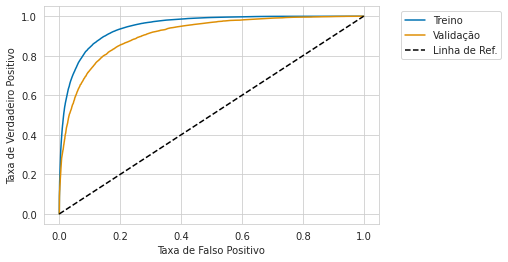

Alvo: 1


Treino  Validação
AUC                  0.931073   0.800301
KS                   0.720113   0.471027
IG                   0.406967   0.154020
Prob_Corte           0.250540   0.211872
Acurácia_Balanceada  0.844992   0.700879

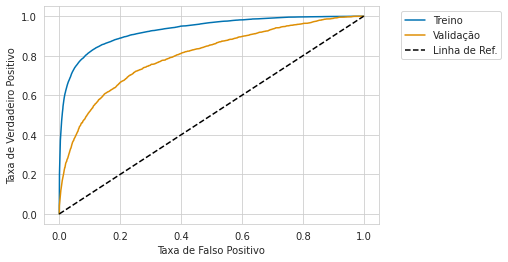

Alvo: 2


Treino  Validação
AUC                  0.939271   0.739399
KS                   0.723437   0.354988
IG                   0.373051   0.076411
Prob_Corte           0.173991   0.086133
Acurácia_Balanceada  0.835498   0.584839

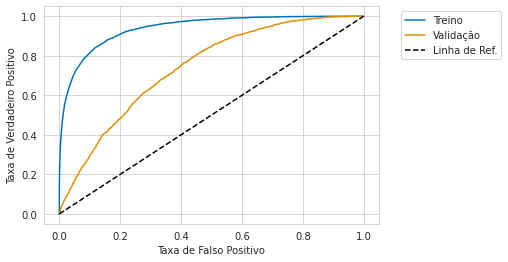

Alvo: 3


Treino  Validação
AUC                  0.943229   0.875581
KS                   0.734619   0.589508
IG                   0.429153   0.258873
Prob_Corte           0.399962   0.327040
Acurácia_Balanceada  0.864438   0.785549

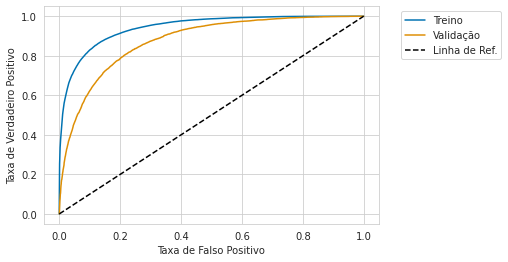

In [ ]:
for alvo in range(0, 4):
  print('Alvo: ' + str(alvo))

  df_train = pd.DataFrame(np.where(y_train == alvo, 1, 0), columns = ['Alvo'])
  df_train['Prob'] = clf_cat.predict_proba(x_train)[:, alvo]

  df_val = pd.DataFrame(np.where(y_val == alvo, 1, 0), columns = ['Alvo'])
  df_val['Prob'] = clf_cat.predict_proba(x_val)[:, alvo]

  dict_dfs = {'Treino': df_train, 'Validação': df_val}
  avaliadfsclf = aml.AvaliaDatasetsClassificacao(dict_dfs, col_alvo = 'Alvo', col_prob = 'Prob', num_div_prob = 1000,
                                                num_div = 10,
                                                frac_cat = 0.05,
                                                chave_treino = 'Treino')

  display(avaliadfsclf.valor_metricas().loc[['AUC', 'KS', 'IG', 'Prob_Corte', 'Acurácia_Balanceada']])

  avaliadfsclf.grafico_roc()
  #avaliadfsclf.grafico_revocacao()
  #avaliadfsclf.grafico_informacao(mostrar_ig_2d = True)
  #avaliadfsclf.grafico_informacao_2d(plot_3d = False)